In [1]:
from pathlib import Path
import os

_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'pyproject.toml').exists()
)
os.chdir(_root)

In [2]:
# Notebook 4 of 4 — New Models & Ensemble
# Inputs : data/processed/ (from 01) + models/ (from 02)
# Outputs: models/ (new pkl files)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
from pathlib import Path
from scipy.stats import randint as sp_randint, uniform as sp_uniform
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import make_scorer
from lightgbm import LGBMClassifier

from aps.training import train_and_evaluate, cost_scorer, get_scores
from aps.evaluation import CalibratorWrapper, tune_threshold, bootstrap_cost_ci

In [3]:
# ── Load preprocessed splits from notebook 01 ────────────────────────────────
X_train_fit  = pd.read_parquet('data/processed/X_train_fit.parquet')
X_val        = pd.read_parquet('data/processed/X_val.parquet')
X_test       = pd.read_parquet('data/processed/X_test.parquet')
y_train_fit  = np.load('data/processed/y_train_fit.npy')
y_val        = np.load('data/processed/y_val.npy')
y_test       = np.load('data/processed/y_test.npy')

# Val split: calibration half + threshold-tuning half (mirrors notebook 03)
X_cal, X_thr, y_cal, y_thr = train_test_split(
    X_val, y_val, test_size=0.5, random_state=42, stratify=y_val)

print(f'Train : {X_train_fit.shape}  pos rate {y_train_fit.mean():.4f}')
print(f'Val   : {X_val.shape}        pos rate {y_val.mean():.4f}')
print(f'Test  : {X_test.shape}       pos rate {y_test.mean():.4f}')

Train : (48000, 178)  pos rate 0.0167
Val   : (12000, 178)        pos rate 0.0167
Test  : (16000, 178)       pos rate 0.0234


In [4]:
# ── Load best existing models for the ensemble ────────────────────────────────
# RF_pre and XGB_pre_with_weights are the top two from notebook 02.
with open('models/RandomForestClassifier_pre_without_weights.pkl', 'rb') as f:
    rf_best = pickle.load(f)
with open('models/XGBClassifier_pre_with_weights.pkl', 'rb') as f:
    xgb_best = pickle.load(f)

with open('models/metadata/cost_dict.json') as f:
    cost_dict = json.load(f)
with open('models/metadata/hardcoded_models.json') as f:
    hardcoded_models = set(json.load(f))

model_dict   = {}
tuned_cost_dict = {}
tuned_thresholds = {}
calibrated_models = {}

print('Loaded RF and XGB best models')

Loaded RF and XGB best models


## LightGBM — pre path

LightGBM's histogram-based boosting handles zero-inflated sparse features efficiently. `scale_pos_weight=50` mirrors the 500/10 cost asymmetry, telling the model that each missed failure is 50× more costly than a false alarm.

In [5]:
lgbm_dist = {
    'n_estimators':     sp_randint(300, 1500),
    'max_depth':        sp_randint(3, 8),
    'num_leaves':       sp_randint(15, 127),
    'learning_rate':    sp_uniform(0.005, 0.095),
    'subsample':        sp_uniform(0.6, 0.4),
    'colsample_bytree': sp_uniform(0.5, 0.5),
    'min_child_samples': sp_randint(5, 50),
    'reg_alpha':        sp_uniform(0.0, 1.0),
    'reg_lambda':       sp_uniform(0.5, 1.5),
    'verbose':          [-1],
    'n_jobs':           [-1],
    'random_state':     [99],
}

# Best params from RandomizedSearchCV (n_iter=30) — hardcoded for reproducibility.
# Set best_params_lgbm_w = None to re-run the search.
best_params_lgbm_w = {
    'n_estimators': 489, 'learning_rate': 0.01659835569656397, 'max_depth': 3,
    'num_leaves': 111, 'min_child_samples': 43,
    'subsample': 0.6002081507981263, 'colsample_bytree': 0.662172510502637,
    'reg_alpha': 0.2721322493846353, 'reg_lambda': 1.4715351808120434,
    'n_jobs': -1, 'random_state': 99, 'verbose': -1,
}

if best_params_lgbm_w is None:
    rs_w = RandomizedSearchCV(
        LGBMClassifier(scale_pos_weight=50, verbose=-1),
        lgbm_dist, n_iter=30, cv=5,
        scoring=make_scorer(cost_scorer),
        random_state=42, n_jobs=1, verbose=1)
    rs_w.fit(X_train_fit, y_train_fit)
    best_params_lgbm_w = rs_w.best_params_
    print(f'Best params (with weights): {best_params_lgbm_w}')

train_and_evaluate(
    LGBMClassifier, {},
    X_train_fit, X_test, y_train_fit, y_test,
    cost_dict, 'pre_with_weights',
    model_dict=model_dict,
    best_params={**best_params_lgbm_w, 'scale_pos_weight': 50, 'verbose': -1, 'n_jobs': -1})


>>> LGBMClassifier_pre_with_weights  train=(48000, 178)  test=(16000, 178)



           ACC    BA     RECALL   PRECISION  F1       ROC-AUC
training  0.963  0.973  0.983    0.311     0.472  0.996
testing   0.964  0.967  0.971    0.390     0.557  0.994

Default-threshold test cost: 11,190


{'n_estimators': 489,
 'learning_rate': 0.01659835569656397,
 'max_depth': 3,
 'num_leaves': 111,
 'min_child_samples': 43,
 'subsample': 0.6002081507981263,
 'colsample_bytree': 0.662172510502637,
 'reg_alpha': 0.2721322493846353,
 'reg_lambda': 1.4715351808120434,
 'n_jobs': -1,
 'random_state': 99,
 'verbose': -1,
 'scale_pos_weight': 50}

In [6]:
# Best params from RandomizedSearchCV (n_iter=30) — hardcoded for reproducibility.
# Set best_params_lgbm_nw = None to re-run the search.
best_params_lgbm_nw = {
    'n_estimators': 1196, 'learning_rate': 0.08263610901911551, 'max_depth': 3,
    'num_leaves': 62, 'min_child_samples': 6,
    'subsample': 0.9530545372757359, 'colsample_bytree': 0.8299920230170895,
    'reg_alpha': 0.9654193512887936, 'reg_lambda': 1.3374401804106464,
    'n_jobs': -1, 'random_state': 99, 'verbose': -1,
}

if best_params_lgbm_nw is None:
    rs_nw = RandomizedSearchCV(
        LGBMClassifier(verbose=-1),
        lgbm_dist, n_iter=30, cv=5,
        scoring=make_scorer(cost_scorer),
        random_state=42, n_jobs=1, verbose=1)
    rs_nw.fit(X_train_fit, y_train_fit)
    best_params_lgbm_nw = rs_nw.best_params_
    print(f'Best params (without weights): {best_params_lgbm_nw}')

train_and_evaluate(
    LGBMClassifier, {},
    X_train_fit, X_test, y_train_fit, y_test,
    cost_dict, 'pre_without_weights',
    model_dict=model_dict,
    best_params={**best_params_lgbm_nw, 'verbose': -1, 'n_jobs': -1})


>>> LGBMClassifier_pre_without_weights  train=(48000, 178)  test=(16000, 178)



           ACC    BA     RECALL   PRECISION  F1       ROC-AUC
training  1.000  0.998  0.995    1.000     0.997  1.000
testing   0.992  0.862  0.725    0.932     0.816  0.993

Default-threshold test cost: 51,700


{'n_estimators': 1196,
 'learning_rate': 0.08263610901911551,
 'max_depth': 3,
 'num_leaves': 62,
 'min_child_samples': 6,
 'subsample': 0.9530545372757359,
 'colsample_bytree': 0.8299920230170895,
 'reg_alpha': 0.9654193512887936,
 'reg_lambda': 1.3374401804106464,
 'n_jobs': -1,
 'random_state': 99,
 'verbose': -1}

## Feature selection

LightGBM's `feature_importances_` (split-based gain) identifies the most predictive sensor channels. Retraining on the top-N features tests whether removing low-signal columns reduces cost further — useful for both interpretability and deployment speed.

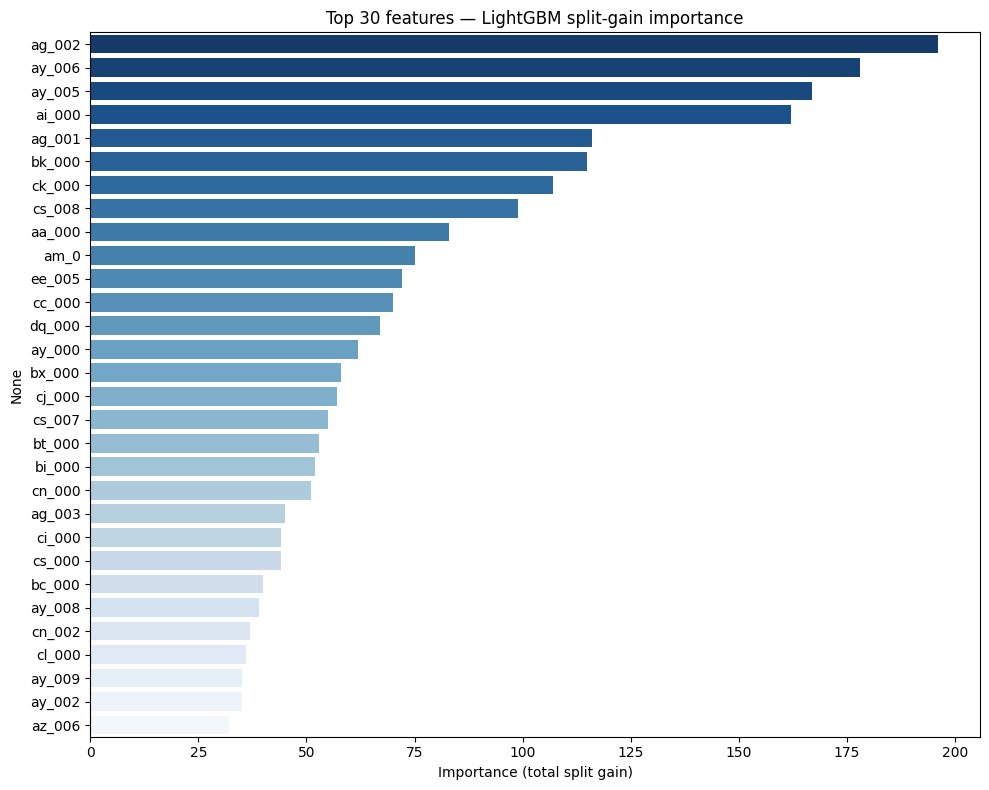

Total features : 178
Zero-importance: 45


In [7]:
lgbm_model = model_dict.get('LGBMClassifier_pre_with_weights')
if lgbm_model is None:
    raise RuntimeError('Run LightGBM training cells first.')

feature_names = X_train_fit.columns.tolist()
importances   = pd.Series(lgbm_model.feature_importances_, index=feature_names)
importances   = importances.sort_values(ascending=False)

# Plot top 30
plt.figure(figsize=(10, 8))
sns.barplot(x=importances.head(30).values, y=importances.head(30).index,
            hue=importances.head(30).index, palette='Blues_r', legend=False)
plt.title('Top 30 features — LightGBM split-gain importance')
plt.xlabel('Importance (total split gain)')
plt.tight_layout()
plt.show()

print(f'Total features : {len(feature_names)}')
print(f'Zero-importance: {(importances == 0).sum()}')

Top  30 features → default-threshold test cost: 12,900


Top  50 features → default-threshold test cost: 12,050


Top  75 features → default-threshold test cost: 11,570


Top 100 features → default-threshold test cost: 10,640


Top 150 features → default-threshold test cost: 12,200


Top 178 features → default-threshold test cost: 11,620


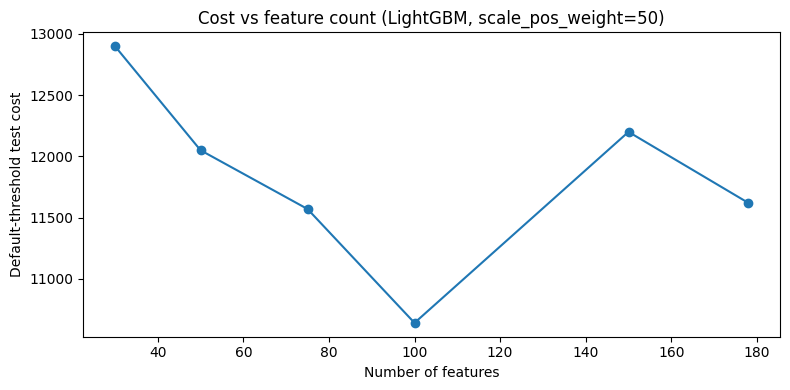

In [8]:
# Select top-N features and retrain — sweep N to find the cost-minimal subset
top_ns   = [30, 50, 75, 100, 150, len(feature_names)]
results  = []

for n in top_ns:
    top_cols = importances.head(n).index.tolist()
    est = LGBMClassifier(**{**best_params_lgbm_w,
                             'scale_pos_weight': 50, 'verbose': -1, 'n_jobs': -1})
    est.fit(X_train_fit[top_cols], y_train_fit)
    y_pred = est.predict(X_test[top_cols])
    from sklearn.metrics import confusion_matrix as _cm
    cm = _cm(y_test, y_pred)
    cost = 10 * cm[0][1] + 500 * cm[1][0]
    results.append({'n_features': n, 'cost': cost})
    print(f'Top {n:3d} features → default-threshold test cost: {cost:,}')

results_df = pd.DataFrame(results)

plt.figure(figsize=(8, 4))
plt.plot(results_df['n_features'], results_df['cost'], marker='o')
plt.xlabel('Number of features')
plt.ylabel('Default-threshold test cost')
plt.title('Cost vs feature count (LightGBM, scale_pos_weight=50)')
plt.tight_layout()
plt.show()

In [9]:
# Train final LightGBM on the optimal feature subset
best_n   = results_df.loc[results_df['cost'].idxmin(), 'n_features']
top_cols = importances.head(int(best_n)).index.tolist()

print(f'Optimal feature count: {best_n}  (cost {results_df["cost"].min():,})')
print(f'Reduced from {len(feature_names)} → {best_n} features  '
      f'({100*(1 - best_n/len(feature_names)):.0f}% reduction)')

# Retrain on reduced feature set; save subset column list for inference
lgbm_reduced = LGBMClassifier(**{**best_params_lgbm_w,
                                   'scale_pos_weight': 50, 'verbose': -1, 'n_jobs': -1})
lgbm_reduced.fit(X_train_fit[top_cols], y_train_fit)

model_dict['LGBMClassifier_pre_with_weights_reduced'] = lgbm_reduced
cost_dict['LGBMClassifier_pre_with_weights_reduced'] = results_df['cost'].min()

# Save the column subset so the reduced model can be used at inference time
Path('models/metadata').mkdir(exist_ok=True)
with open('models/metadata/lgbm_reduced_features.json', 'w') as f:
    json.dump(top_cols, f, indent=2)
print(f'Feature list saved → models/metadata/lgbm_reduced_features.json')

Optimal feature count: 100  (cost 10,640)
Reduced from 178 → 100 features  (44% reduction)


Feature list saved → models/metadata/lgbm_reduced_features.json


## Ensemble

RF, XGBoost, and LightGBM are statistically tied at the top. A soft-voting ensemble averages their calibrated probability estimates — reducing variance without the cost of retraining. Each model is individually calibrated with Platt scaling first so their probability scales are comparable before averaging.

In [10]:
# Calibrate the three best models individually
for name, est in [
    ('RandomForestClassifier_pre_without_weights', rf_best),
    ('XGBClassifier_pre_with_weights',             xgb_best),
    ('LGBMClassifier_pre_with_weights',            model_dict['LGBMClassifier_pre_with_weights']),
]:
    cal = CalibratorWrapper(est, method='sigmoid').fit(X_cal, y_cal)
    calibrated_models[name] = cal
    print(f'  {name}: calibrated (Platt)')

  RandomForestClassifier_pre_without_weights: calibrated (Platt)
  XGBClassifier_pre_with_weights: calibrated (Platt)
  LGBMClassifier_pre_with_weights: calibrated (Platt)


In [11]:
# Soft-voting ensemble: average calibrated probabilities
# (Avoids sklearn VotingClassifier re-fitting pre-trained estimators)
class SoftEnsemble:
    def __init__(self, estimators: list):
        self.estimators = estimators

    def predict_proba(self, X) -> np.ndarray:
        probas = np.mean(
            [e.predict_proba(X)[:, 1] for e in self.estimators], axis=0)
        return np.column_stack([1 - probas, probas])

    def predict(self, X) -> np.ndarray:
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


ensemble = SoftEnsemble([
    calibrated_models['RandomForestClassifier_pre_without_weights'],
    calibrated_models['XGBClassifier_pre_with_weights'],
    calibrated_models['LGBMClassifier_pre_with_weights'],
])
calibrated_models['Ensemble_RF_XGB_LGBM'] = ensemble

y_pred_default = ensemble.predict(X_test)
from sklearn.metrics import confusion_matrix as _cm2
cm = _cm2(y_test, y_pred_default)
cost_dict['Ensemble_RF_XGB_LGBM'] = 10 * cm[0][1] + 500 * cm[1][0]
print(f'Ensemble default-threshold test cost: {cost_dict["Ensemble_RF_XGB_LGBM"]:,}')

Ensemble default-threshold test cost: 50,540


## Calibration + threshold tuning

In [12]:
# Also calibrate reduced LGBM for threshold tuning
cal_reduced = CalibratorWrapper(lgbm_reduced, method='sigmoid').fit(
    X_cal[top_cols], y_cal)
calibrated_models['LGBMClassifier_pre_with_weights_reduced'] = cal_reduced

# Wrap reduced model so tune_threshold sees correct feature set
class ReducedFeatureWrapper:
    def __init__(self, estimator, cols):
        self.estimator = estimator
        self.cols = cols
    def predict_proba(self, X):
        return self.estimator.predict_proba(X[self.cols])

calibrated_models['LGBMClassifier_pre_with_weights_reduced'] = ReducedFeatureWrapper(
    cal_reduced, top_cols)

print('All new models calibrated')

All new models calibrated


In [13]:
print('=== Decision-threshold tuning — new models ===\n')
new_models = [
    'LGBMClassifier_pre_with_weights',
    'LGBMClassifier_pre_with_weights_reduced',
    'Ensemble_RF_XGB_LGBM',
]
for name in new_models:
    est = calibrated_models[name]
    best_t, cost_tuned = tune_threshold(est, X_thr, y_thr, X_test, y_test, name)
    if cost_tuned is not None:
        tuned_cost_dict[name] = cost_tuned
        tuned_thresholds[name] = best_t

=== Decision-threshold tuning — new models ===



LGBMClassifier_pre_with_weights:
  default threshold -> test cost 22,560
  tuned  threshold  -> test cost 9,940  (saves 12,620, 55.9%)



LGBMClassifier_pre_with_weights_reduced:
  default threshold -> test cost 22,620
  tuned  threshold  -> test cost 10,090  (saves 12,530, 55.4%)



Ensemble_RF_XGB_LGBM:
  default threshold -> test cost 25,490
  tuned  threshold  -> test cost 10,610  (saves 14,880, 58.4%)



In [14]:
print('=== 95% Bootstrap CIs — new models ===\n')
print(f'{"Model":<52} {"Point":>8}   {"95% CI"}')
print('-' * 80)
for name in new_models:
    if name not in tuned_cost_dict or name not in tuned_thresholds:
        continue
    est   = calibrated_models[name]
    sc    = est.predict_proba(X_test)[:, 1]
    y_pred = (sc >= tuned_thresholds[name]).astype(int)
    lo, hi = bootstrap_cost_ci(y_pred, y_test)
    print(f'{name:<52} {tuned_cost_dict[name]:>8,}   [{lo:,} – {hi:,}]')

=== 95% Bootstrap CIs — new models ===

Model                                                   Point   95% CI
--------------------------------------------------------------------------------


LGBMClassifier_pre_with_weights                         9,940   [7,869 – 12,261]


LGBMClassifier_pre_with_weights_reduced                10,090   [7,618 – 12,850]


Ensemble_RF_XGB_LGBM                                   10,610   [7,549 – 14,021]


## Final comparison

In [15]:
# Load notebook-02 tuned costs for reference
with open('models/metadata/cost_dict.json') as f:
    cost_dict_nb02 = json.load(f)

# Build combined ranking: nb02 best + new models
# (tuned costs from nb02 are stored separately — load if available)
import os
nb02_tuned_path = 'models/metadata/tuned_cost_dict_nb03.json'
if os.path.exists(nb02_tuned_path):
    with open(nb02_tuned_path) as f:
        all_tuned = json.load(f)
else:
    # Fall back to default-threshold costs from nb02 if tuned not saved
    all_tuned = dict(cost_dict_nb02)

all_tuned.update(tuned_cost_dict)

ranked = sorted(all_tuned.items(), key=lambda x: x[1])
print(f'{"Model":<52} {"Tuned cost":>12}')
print('-' * 66)
for name, cost in ranked:
    flag = ' †' if name in hardcoded_models else ''
    print(f'{name:<52} {cost:>12,}{flag}')

baseline = 500 * int(y_test.sum())
best_name, best_cost = ranked[0]
print(f'\nBaseline (all-neg): {baseline:,}')
print(f'Best model        : {best_name}  ({best_cost:,})')
print(f'Reduction vs baseline: {(baseline - best_cost)/baseline*100:.1f}%')

Model                                                  Tuned cost
------------------------------------------------------------------
RandomForestClassifier_pre_without_weights                  9,190
LGBMClassifier_pre_with_weights                             9,940
LGBMClassifier_pre_with_weights_reduced                    10,090
Ensemble_RF_XGB_LGBM                                       10,610
XGBClassifier_pre_with_weights                             11,280
RandomForestClassifier_post_without_weights                11,640
RandomForestClassifier_smote_without_weights               12,020 †
XGBClassifier_post_without_weights                         13,390
RandomForestClassifier_pre_with_weights                    14,780
LogisticRegression_pre_without_weights                     16,150
LogisticRegression_pre_with_weights                        16,520
LogisticRegression_smote_without_weights                   17,750
XGBClassifier_smote_without_weights                        17,900 †
MLPCl

In [16]:
# Save new models and updated metadata
for name, est in model_dict.items():
    path = f'models/{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(est, f)
    print(f'Saved {name}')

# Persist tuned costs so notebook 03 comparison can include new results
all_tuned_save = {**cost_dict_nb02, **tuned_cost_dict}
with open('models/metadata/tuned_cost_dict.json', 'w') as f:
    json.dump({k: int(v) for k, v in all_tuned_save.items()}, f, indent=2)
print('\nSaved models/metadata/tuned_cost_dict.json')

Saved LGBMClassifier_pre_with_weights
Saved LGBMClassifier_pre_without_weights
Saved LGBMClassifier_pre_with_weights_reduced

Saved models/metadata/tuned_cost_dict.json


## Inference pipelines

Each inference pipeline chains `ColumnDropper → MedianImputerWithIndicators → WinsorizerTransformer → Model` into a single serializable object. Input: raw feature DataFrame (no label column, NaN for missing values). Output: binary predictions + calibrated probabilities.

In [17]:
import pickle
from aps.preprocessing import build_inference_pipeline

# Load fitted preprocessing artefacts saved by notebook 01
with open('models/col_dropper.pkl', 'rb') as f:
    col_dropper = pickle.load(f)
with open('models/feature_pipeline.pkl', 'rb') as f:
    feature_pipeline_fitted = pickle.load(f)

# Load feature subset list for the reduced LGBM model
with open('models/metadata/lgbm_reduced_features.json') as f:
    lgbm_reduced_cols = json.load(f)

print(f'col_dropper     : keeps {len(col_dropper.cols_to_keep_)} columns')
print(f'feature_pipeline: {list(feature_pipeline_fitted.named_steps.keys())}')
print(f'LGBM reduced    : {len(lgbm_reduced_cols)} features')

col_dropper     : keeps 162 columns
feature_pipeline: ['imputer', 'winsoriser']
LGBM reduced    : 100 features


In [18]:
# Build one inference pipeline per top model
top_models = {
    'RF_pre':           ('RandomForestClassifier_pre_without_weights', None),
    'LGBM_pre':         ('LGBMClassifier_pre_with_weights',            None),
    'LGBM_pre_reduced': ('LGBMClassifier_pre_with_weights_reduced',    lgbm_reduced_cols),
}

Path('models/inference').mkdir(exist_ok=True)
inference_pipelines = {}

for alias, (model_name, feature_cols) in top_models.items():
    with open(f'models/{model_name}.pkl', 'rb') as f:
        base_model = pickle.load(f)

    pipe = build_inference_pipeline(
        col_dropper, feature_pipeline_fitted, base_model, feature_cols)
    inference_pipelines[alias] = pipe

    out_path = f'models/inference/{alias}.pkl'
    with open(out_path, 'wb') as f:
        pickle.dump(pipe, f)
    print(f'Saved {out_path}')

Saved models/inference/RF_pre.pkl
Saved models/inference/LGBM_pre.pkl
Saved models/inference/LGBM_pre_reduced.pkl


### Smoke test

Feed a raw row from the test CSV through each pipeline and verify we get a prediction and a probability out — end-to-end, no manual preprocessing.

In [19]:
# Load raw test CSV exactly as a user would
df_raw = pd.read_csv('data/aps_failure_test_set.csv', skiprows=20, na_values='na')
X_raw  = df_raw.drop(columns=['class'])   # label column removed — pipeline is for prediction

print(f'Raw input shape: {X_raw.shape}  (171 original columns, NaN for missing)')
print()

for alias, pipe in inference_pipelines.items():
    sample = X_raw.iloc[:5]
    y_pred  = pipe.predict(sample)
    y_proba = pipe.predict_proba(sample)[:, 1]
    print(f'{alias}:')
    print(f'  predictions  : {y_pred.tolist()}')
    print(f'  probabilities: {[round(p, 4) for p in y_proba.tolist()]}')
    print()

print('All inference pipelines working end-to-end.')

Raw input shape: (16000, 170)  (171 original columns, NaN for missing)



RF_pre:
  predictions  : [0, 0, 0, 0, 0]
  probabilities: [0.0003, 0.0003, 0.0011, 0.0003, 0.0003]

LGBM_pre:
  predictions  : [0, 0, 0, 0, 0]
  probabilities: [0.0204, 0.007, 0.055, 0.0017, 0.0122]

LGBM_pre_reduced:
  predictions  : [0, 0, 0, 0, 0]
  probabilities: [0.0269, 0.0065, 0.1143, 0.0021, 0.0118]

All inference pipelines working end-to-end.
